## Dense Net for age predictions
- train a DenseNet on all age groups
- produce fold-safe out-of-fold predictions for the development set
- produce predictions for the test set to extend Random Forest features

In [1]:
import csv
import pandas as pd
import numpy as np

### 1. Load and prepare the dataset
- keep all age groups for DenseNet training

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/ML/"
X_dev_final = "X_dev_final.csv"
y_file = "y_train.csv"
X_test_final = "X_test_final.csv"
X_dev = pd.read_csv(drive_path + X_dev_final)
y_file = pd.read_csv(drive_path + y_file)
X_test = pd.read_csv(drive_path + X_test_final)

assert X_dev.shape[0] == y_file.shape[0], "Number of samples in X_dev and y_file must be the same."
# check weather column names of test and dev are matching except for fold column
print("Column names in X_dev:", set(X_dev.columns))
print("Column names in X_test:", set(X_test.columns))
print("Columns in y_file:", set(y_file.columns))
print("Columns in X_dev but not in X_test:", set(X_dev.columns) - set(X_test.columns))
print("Columns in X_test but not in X_dev:", set(X_test.columns) - set(X_dev.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Column names in X_dev: {'cancer_history', 'region_ARM', 'diameter_1', 'fold', 'region_EAR', 'perimeter', 'roundness', 'region_ABDOMEN', 'background_mother_UNK', 'gender', 'background_mother_NORWAY', 'background_father_CZECH', 'lbp_bin_2', 'mean_B', 'background_mother_GERMANY', 'diameter_2', 'edge_count', 'lbp_bin_0', 'img_id', 'changed', 'grew', 'bleed', 'background_mother_SPAIN', 'mean_G', 'background_father_GERMANY', 'region_NECK', 'region_BACK', 'std_B', 'background_father_AUSTRIA', 'background_father_ISRAEL', 'region_THIGH', 'background_father_POMERANIA', 'background_mother_NETHERLANDS', 'background_mother_POLAND', 'background_mother_PORTUGAL', 'background_father_BRAZIL', 'has_sewage_system', 'hurt', 'background_father_PORTUGAL', 'fitspatrick', 'background_father_POLAND', 'region_NOSE', 'skin_cancer_history', 'elevation', 'background_mother_POMERANIA', 'r

In [3]:
# keep all rows (all age groups)
print("Number of rows in X_dev (all ages):", X_dev.shape[0])
print("Number of rows in X_test (all ages):", X_test.shape[0])

X_dev_DenseNet = X_dev.copy()
X_test_DenseNet = X_test.copy()

print("Number of rows in X_dev_DenseNet:", X_dev_DenseNet.shape[0])
print("Number of rows in X_test_DenseNet:", X_test_DenseNet.shape[0])

Number of rows in X_dev (all ages): 1178
Number of rows in X_test (all ages): 296
Number of rows in X_dev_DenseNet: 1178
Number of rows in X_test_DenseNet: 296


In [4]:
def print_fine_labels(fold_index, y_file, fold_name):
    dict_fine_label_counter = {
        'ACK':    0,
        'SCC':    0,
        'MEL':    0,
        'NEV':   0,
        'SEK':    0,
        'BCC':    0
    }
    for i in fold_index:
        label = y_file.loc[i,'fine_label']
        match label:
            case "ACK":
                dict_fine_label_counter['ACK'] += 1
            case "SCC":
                dict_fine_label_counter['SCC'] += 1
            case "MEL":
                dict_fine_label_counter['MEL'] += 1
            case "NEV":
                dict_fine_label_counter['NEV'] += 1
            case "SEK":
                dict_fine_label_counter['SEK'] += 1
            case "BCC":
                dict_fine_label_counter['BCC'] += 1
            case _:
                print(f"Unknown label: {label}")
    print(f"Fine label distribution in {fold_name}:")
    for label, count in dict_fine_label_counter.items():
        print(f"{label}: {count}")
    print("len of fold index:", len(fold_index.tolist()))
    

fold0_rows_dev = X_dev_DenseNet[X_dev_DenseNet['fold'] == 0].index
fold1_rows_dev = X_dev_DenseNet[X_dev_DenseNet['fold'] == 1].index
fold2_rows_dev = X_dev_DenseNet[X_dev_DenseNet['fold'] == 2].index
fold3_rows_dev = X_dev_DenseNet[X_dev_DenseNet['fold'] == 3].index
fold4_rows_dev = X_dev_DenseNet[X_dev_DenseNet['fold'] == 4].index


print_fine_labels(fold0_rows_dev, y_file, "Fold 0")

print_fine_labels(fold1_rows_dev, y_file, "Fold 1")

print_fine_labels(fold2_rows_dev, y_file, "Fold 2")

print_fine_labels(fold3_rows_dev, y_file, "Fold 3")

print_fine_labels(fold4_rows_dev, y_file, "Fold 4")

#drop all features except the fold column and the img_id column
X_dev_final_DenseNet = X_dev_DenseNet.drop(X_dev_DenseNet.columns.difference(['fold', 'img_id']), axis=1)
X_test_final_DenseNet = X_test_DenseNet.drop(X_test_DenseNet.columns.difference(['fold', 'img_id']), axis=1)
print("Columns in X_dev_final_DenseNet:", set(X_dev_final_DenseNet.columns))
print("Columns in X_test_final_DenseNet:", set(X_test_final_DenseNet.columns))

Fine label distribution in Fold 0:
ACK: 44
SCC: 17
MEL: 17
NEV: 14
SEK: 7
BCC: 137
len of fold index: 236
Fine label distribution in Fold 1:
ACK: 43
SCC: 35
MEL: 7
NEV: 8
SEK: 5
BCC: 137
len of fold index: 235
Fine label distribution in Fold 2:
ACK: 41
SCC: 34
MEL: 11
NEV: 15
SEK: 5
BCC: 129
len of fold index: 235
Fine label distribution in Fold 3:
ACK: 48
SCC: 37
MEL: 3
NEV: 11
SEK: 5
BCC: 131
len of fold index: 235
Fine label distribution in Fold 4:
ACK: 42
SCC: 31
MEL: 3
NEV: 9
SEK: 10
BCC: 142
len of fold index: 237
Columns in X_dev_final_DenseNet: {'img_id', 'fold'}
Columns in X_test_final_DenseNet: {'img_id'}


In [5]:
#load images
import gdown
!gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
!gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
img_file_dev = "x_train_img.npz"
img_file_test = "x_test_img.npz"

# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")  
    return img, ids

imgs, img_ids = load_img_data(img_file_dev)
print(img_ids.shape, imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"

imgs_test, img_ids_test = load_img_data(img_file_test)
assert np.all(img_ids_test == X_test['img_id']), "Image IDs in test metadata and test image data do not match"

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=603da997-c687-4ea7-8acf-1f724221b050
To: /content/x_train_img.npz
100% 177M/177M [00:00<00:00, 240MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=96191be2-29f7-41c4-bce9-10d0a5a59b7d
To: /content/x_test_img.npz
100% 49.0M/49.0M [00:00<00:00, 195MB/s]
Successfully loaded 1178 images.
(1178,) (1178, 256, 256, 3)
Successfully loaded 296 images.


### 2. Train DenseNet121
- train DenseNet on the full development set (all ages)
- produce out-of-fold predictions for dev and predictions for test

In [6]:
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
# Step 1: load ImageNet pretrained DenseNet121
weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights).to(device)
print("Loaded pretrained DenseNet121")

Loaded pretrained DenseNet121


In [8]:
# Step 2: replace classifier for 6 classes
class_names = ["BCC", "ACK", "SCC", "NEV", "MEL", "SEK"]
num_classes = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)
model = model.to(device)
print("New classifier:", model.classifier)

New classifier: Linear(in_features=1024, out_features=6, bias=True)


In [ ]:
# torchvision-only pipeline: no extra augmentation package needed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 21.1 MB/s eta 0:00:0000:01


In [12]:
"""
Torchvision-only image augmentation classes.
Compatible with current Colab (NumPy 2.x, Python 3.12).
"""

import torchvision
from torchvision import transforms as T


class ImgTrainTransform:

    def __init__(self, size=(224, 224), normalization=([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])):

        self.transforms = T.Compose([
            T.ToPILImage(),
            T.RandomResizedCrop(size=size, scale=(0.7, 1.0), ratio=(0.8, 1.25)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.RandomRotation(degrees=30),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            T.ToTensor(),
            T.Normalize(normalization[0], normalization[1]),
            T.RandomErasing(p=0.2, scale=(0.01, 0.08), ratio=(0.3, 3.3), value="random"),
        ])

    def __call__(self, img):
        return self.transforms(img)


class ImgEvalTransform:

    def __init__(self, size=(224, 224), normalization=([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])):

        self.transforms = T.Compose([
            T.ToPILImage(),
            T.Resize(size),
            T.ToTensor(),
            T.Normalize(normalization[0], normalization[1]),
        ])

    def __call__(self, img):
        return self.transforms(img)

In [20]:
# Step 5-7: fold training, loss tracking, OOF + test predictions
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

batch_size = 32
epochs = 20
warmup_epochs = 4
lr_head = 1e-3
lr_finetune = 1e-4
weight_decay = 1e-4
label_smoothing = 0.0
early_stopping_patience = 3
early_stopping_min_delta = 0.003

senior_dev_idx = X_dev_DenseNet.index.to_numpy()
senior_test_idx = X_test_DenseNet.index.to_numpy()

dev_imgs = imgs[senior_dev_idx]
test_imgs = imgs_test[senior_test_idx]

dev_folds = X_dev_final_DenseNet["fold"].to_numpy()
dev_labels_str = y_file.loc[senior_dev_idx, "fine_label"].to_numpy()
dev_labels = np.array([class_to_idx[x] for x in dev_labels_str], dtype=np.int64)

print("Samples in dev (all ages):", len(senior_dev_idx))
print("Samples in test (all ages):", len(senior_test_idx))
print("Classes:", class_names)


class SeniorImageDataset(Dataset):
    def __init__(self, images, labels=None, indices=None, transform=None):
        self.images = images
        self.labels = labels
        self.indices = np.arange(len(images)) if indices is None else np.array(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        image = self.images[idx]
        if self.transform is not None:
            image = self.transform(image)
        if self.labels is None:
            return image, idx
        return image, self.labels[idx], idx


def make_model(num_classes):
    fold_model = models.densenet121(weights=weights)
    in_features = fold_model.classifier.in_features
    fold_model.classifier = nn.Linear(in_features, num_classes)
    return fold_model.to(device)


def freeze_backbone(model_to_freeze):
    for p in model_to_freeze.features.parameters():
        p.requires_grad = False
    for p in model_to_freeze.classifier.parameters():
        p.requires_grad = True


def unfreeze_all(model_to_unfreeze):
    for p in model_to_unfreeze.parameters():
        p.requires_grad = True


criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
unique_folds = sorted(np.unique(dev_folds))

history = {}
oof_probs = np.zeros((len(dev_imgs), num_classes), dtype=np.float32)
test_fold_probs = []

for fold in unique_folds:
    print(f"\n===== Fold {fold} =====")
    train_idx = np.where(dev_folds != fold)[0]
    val_idx = np.where(dev_folds == fold)[0]
    print("train size:", len(train_idx), "val size:", len(val_idx))

    train_ds = SeniorImageDataset(dev_imgs, labels=dev_labels, indices=train_idx, transform=ImgTrainTransform())
    val_ds = SeniorImageDataset(dev_imgs, labels=dev_labels, indices=val_idx, transform=ImgEvalTransform())
    test_ds = SeniorImageDataset(test_imgs, labels=None, indices=None, transform=ImgEvalTransform())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    fold_model = make_model(num_classes)

    # Stage 1: train classifier head only
    freeze_backbone(fold_model)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=lr_head,
        weight_decay=weight_decay,
    )
    scheduler = None

    history[fold] = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val_loss = float("inf")
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # Stage 2: unfreeze all layers and fine-tune at lower lr
        if epoch == warmup_epochs + 1:
            unfreeze_all(fold_model)
            optimizer = torch.optim.Adam(
                fold_model.parameters(),
                lr=lr_finetune,
                weight_decay=weight_decay,
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=2,
                min_lr=1e-6,
            )
            print("Unfroze backbone and switched to fine-tuning lr.")

        fold_model.train()
        train_loss_sum = 0.0

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = fold_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_ds)

        fold_model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = fold_model(xb)
                loss = criterion(logits, yb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_ds)

        if scheduler is not None:
            scheduler.step(val_loss)

        history[fold]["train_loss"].append(train_loss)
        history[fold]["val_loss"].append(val_loss)

        if val_loss < (best_val_loss - early_stopping_min_delta):
            best_val_loss = val_loss
            best_state = copy.deepcopy(fold_model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:02d}/{epochs}  lr={current_lr:.6f}  "
            f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}"
        )

        if bad_epochs >= early_stopping_patience:
            print(
                f"Early stopping at epoch {epoch} "
                f"(best val_loss={best_val_loss:.4f})."
            )
            break

    fold_model.load_state_dict(best_state)
    fold_model.eval()

    with torch.no_grad():
        for xb, _, original_idx in val_loader:
            xb = xb.to(device)
            probs = torch.softmax(fold_model(xb), dim=1).cpu().numpy()
            oof_probs[original_idx.numpy()] = probs

    fold_test_probs = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            probs = torch.softmax(fold_model(xb), dim=1).cpu().numpy()
            fold_test_probs.append(probs)

    test_fold_probs.append(np.vstack(fold_test_probs))

Samples in dev (all ages): 1178
Samples in test (all ages): 296
Classes: ['BCC', 'ACK', 'SCC', 'NEV', 'MEL', 'SEK']

===== Fold 0 =====
train size: 942 val size: 236
Epoch 01/20  lr=0.001000  train_loss=1.3171  val_loss=1.3194
Epoch 02/20  lr=0.001000  train_loss=1.1889  val_loss=1.1979
Epoch 03/20  lr=0.001000  train_loss=1.1561  val_loss=1.1686
Epoch 04/20  lr=0.001000  train_loss=1.0971  val_loss=1.1472
Unfroze backbone and switched to fine-tuning lr.
Epoch 05/20  lr=0.000100  train_loss=1.0070  val_loss=0.9914
Epoch 06/20  lr=0.000100  train_loss=0.8383  val_loss=0.9323
Epoch 07/20  lr=0.000100  train_loss=0.7324  val_loss=0.9252
Epoch 08/20  lr=0.000100  train_loss=0.6286  val_loss=0.9148
Epoch 09/20  lr=0.000100  train_loss=0.5519  val_loss=0.9080
Epoch 10/20  lr=0.000100  train_loss=0.4531  val_loss=0.9412
Epoch 11/20  lr=0.000100  train_loss=0.4247  val_loss=0.9328
Epoch 12/20  lr=0.000050  train_loss=0.3640  val_loss=0.9844
Early stopping at epoch 12 (best val_loss=0.9080).

=

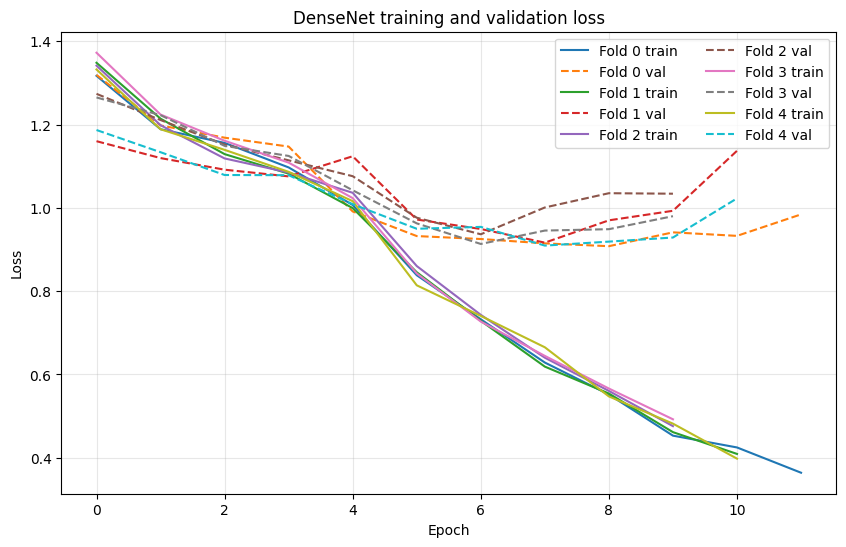

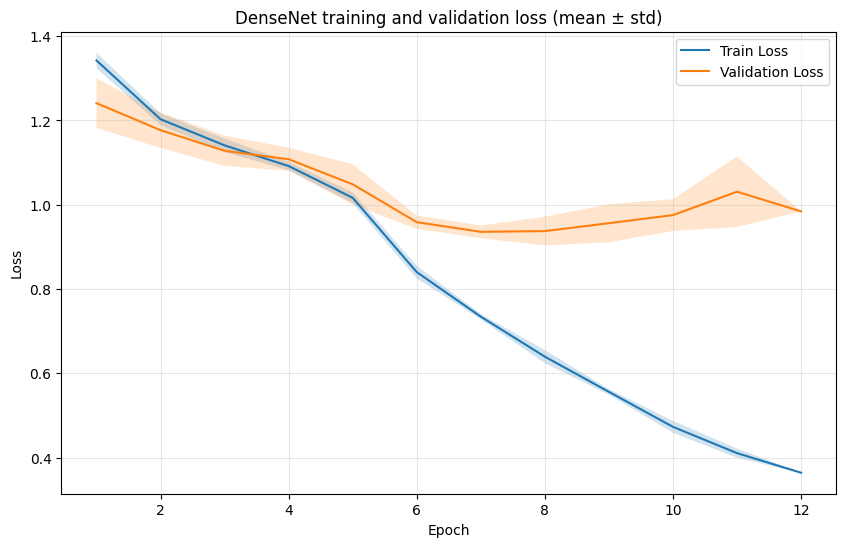

In [21]:

# Step 6: plot train/val loss for each fold
plt.figure(figsize=(10, 6))
for fold in unique_folds:
    plt.plot(history[fold]["train_loss"], label=f"Fold {fold} train")
    plt.plot(history[fold]["val_loss"], linestyle="--", label=f"Fold {fold} val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet training and validation loss")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

#plot validation and train loss as one function average over folds
# and with std for each fold represented by a bar\
plt.figure(figsize=(10, 6))
train_loss_means = []
train_loss_stds = []
val_loss_means = []
val_loss_stds = []
for epoch in range(len(history[0]["train_loss"])):
    train_losses = [history[fold]["train_loss"][epoch] for fold in unique_folds if epoch < len(history[fold]["train_loss"])]
    val_losses = [history[fold]["val_loss"][epoch] for fold in unique_folds if epoch < len(history[fold]["val_loss"])]
    train_loss_means.append(np.mean(train_losses))
    train_loss_stds.append(np.std(train_losses))
    val_loss_means.append(np.mean(val_losses))
    val_loss_stds.append(np.std(val_losses))
epochs_range = range(1, len(train_loss_means) + 1)
plt.plot(epochs_range, train_loss_means, label="Train Loss")
plt.fill_between(epochs_range, np.array(train_loss_means) - np.array(train_loss_stds), np.array(train_loss_means) + np.array(train_loss_stds), alpha=0.2)
plt.plot(epochs_range, val_loss_means, label="Validation Loss")
plt.fill_between(epochs_range, np.array(val_loss_means) - np.array(val_loss_stds), np.array(val_loss_means) + np.array(val_loss_stds), alpha=0.2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet training and validation loss (mean ± std)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [22]:


# Step 7: leakage-safe OOF and fold-averaged test predictions for seniors
test_probs = np.mean(np.stack(test_fold_probs, axis=0), axis=0)

score_cols = [f"densenet_prob_{c}" for c in class_names]

dev_scores_full = pd.DataFrame(-1.0, index=X_dev.index, columns=score_cols)
test_scores_full = pd.DataFrame(-1.0, index=X_test.index, columns=score_cols)

dev_scores_full.loc[senior_dev_idx, score_cols] = oof_probs
test_scores_full.loc[senior_test_idx, score_cols] = test_probs

dev_scores_full = dev_scores_full.reset_index(drop=True)
test_scores_full = test_scores_full.reset_index(drop=True)

print("OOF senior matrix:", oof_probs.shape)
print("Test senior matrix:", test_probs.shape)
print("Full dev feature matrix:", dev_scores_full.shape)
print("Full test feature matrix:", test_scores_full.shape)

# optional export
dev_scores_full.to_csv("densenet_oof_dev_scores.csv", index=False)
test_scores_full.to_csv("densenet_test_scores.csv", index=False)

OOF senior matrix: (1178, 6)
Test senior matrix: (296, 6)
Full dev feature matrix: (1178, 6)
Full test feature matrix: (296, 6)


In [ ]:
# train on all datapoints for final test predictions (seniors only)
if "history" in globals() and len(history) > 0:
    best_epochs = [int(np.argmin(history[f]["val_loss"])) + 1 for f in sorted(history.keys())]
    final_epochs = int(np.clip(round(float(np.mean(best_epochs))), 8, epochs))
else:
    best_epochs = []
    final_epochs = 12

final_warmup_epochs = min(warmup_epochs, max(2, final_epochs // 3))

print("Per-fold best epochs:", best_epochs if best_epochs else "n/a")
print("Final full-data epochs:", final_epochs)
print("Final warmup epochs:", final_warmup_epochs)

full_train_ds = SeniorImageDataset(dev_imgs, labels=dev_labels, indices=None, transform=ImgTrainTransform())
full_test_ds = SeniorImageDataset(test_imgs, labels=None, indices=None, transform=ImgEvalTransform())

full_train_loader = DataLoader(full_train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
full_test_loader = DataLoader(full_test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

final_model = make_model(num_classes)
freeze_backbone(final_model)
final_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, final_model.parameters()),
    lr=lr_head,
    weight_decay=weight_decay,
)

for epoch in range(1, final_epochs + 1):
    if epoch == final_warmup_epochs + 1:
        unfreeze_all(final_model)
        final_optimizer = torch.optim.Adam(
            final_model.parameters(),
            lr=lr_finetune,
            weight_decay=weight_decay,
        )
        print("Final model: unfroze backbone and switched to fine-tuning lr.")

    final_model.train()
    train_loss_sum = 0.0

    for xb, yb, _ in full_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        final_optimizer.zero_grad()
        logits = final_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        final_optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)

    epoch_loss = train_loss_sum / len(full_train_ds)
    current_lr = final_optimizer.param_groups[0]["lr"]
    print(f"Final model epoch {epoch:02d}/{final_epochs}  lr={current_lr:.6f}  train_loss={epoch_loss:.4f}")

# infer test probabilities from the full-data model
final_model.eval()
final_test_parts = []
with torch.no_grad():
    for xb, _ in full_test_loader:
        xb = xb.to(device)
        probs = torch.softmax(final_model(xb), dim=1).cpu().numpy()
        final_test_parts.append(probs)

test_probs_full_model = np.vstack(final_test_parts)

score_cols = [f"densenet_prob_{c}" for c in class_names]
test_scores_full_model = pd.DataFrame(-1.0, index=X_test.index, columns=score_cols)
test_scores_full_model.loc[senior_test_idx, score_cols] = test_probs_full_model
test_scores_full_model = test_scores_full_model.reset_index(drop=True)

print("Full-data senior test matrix:", test_probs_full_model.shape)
print("Full-data full test feature matrix:", test_scores_full_model.shape)

# optional comparison to fold-averaged predictions from Cell 16
if "test_scores_full" in globals():
    mae = np.mean(np.abs(test_scores_full_model[score_cols].values - test_scores_full[score_cols].values))
    print(f"MAE vs fold-averaged test features: {mae:.6f}")

# export final full-data-model test features
test_scores_full_model.to_csv("densenet_test_scores_full_model.csv", index=False)

Per-fold best epochs: [9, 8, 7, 7, 8]
Final full-data epochs: 8
Final warmup epochs: 2
Final model epoch 01/8  lr=0.001000  train_loss=1.3599
Final model epoch 02/8  lr=0.001000  train_loss=1.1984
Final model: unfroze backbone and switched to fine-tuning lr.
Final model epoch 03/8  lr=0.000100  train_loss=1.0695
Final model epoch 04/8  lr=0.000100  train_loss=0.8700
Final model epoch 05/8  lr=0.000100  train_loss=0.7593
Final model epoch 06/8  lr=0.000100  train_loss=0.6625
Final model epoch 07/8  lr=0.000100  train_loss=0.5863
Final model epoch 08/8  lr=0.000100  train_loss=0.5306
Full-data senior test matrix: (296, 6)
Full-data full test feature matrix: (296, 6)
MAE vs fold-averaged test features: 0.060919
